# Face Verification for Secure Access — SIFT Keypoint Matching vs Deep Face Embeddings

**Computer Vision course project (AIGS1010) · Post-Graduate Diploma in AI & Data Science, Loyalist College**

A person enrolls with a few photos. When someone asks for access, their face is compared with the enrolled photos, and access is **permitted** only if the match is strong enough.

Two approaches:
1. **Classical computer vision (OpenCV):** Haar-cascade face detection, then **SIFT** keypoints and descriptors, **FLANN** nearest-neighbour matching, and **Lowe's ratio test**. The similarity score is the share of keypoints with a good match.
2. **Deep learning (dlib / `face_recognition`):** a pre-trained network turns each face into a 128-number embedding. Two faces belong to the same person if their embeddings are close.

**Dataset:** [Georgia Tech Face Database](http://www.anefian.com/research/face_reco.htm): 50 people × 15 colour photos (640×480) with different expressions, lighting and angles. It isn't included in this repo; see *Setup*.

## Results (approach 1, evaluated on 25 people not used for tuning)
| Method | ROC AUC | At the chosen threshold |
|---|---|---|
| Original version: compare the *number* of keypoints | **0.71** (weak) | not usable as a security check |
| **This version: SIFT + FLANN + ratio test** | **0.93** | 6.8% of impostors accepted, 17.8% of genuine users rejected |

> **Revision note:** the first version of this notebook detected SIFT keypoints but never *matched* them. It compared how *many* keypoints each face had, so any two faces with similar counts looked alike, and an impostor was let in during the demo. This version matches descriptors (FLANN + ratio test), chooses the threshold on held-out people, and measures error rates on 25 people it has never seen.

## Setup
Download the Georgia Tech face database and unzip it so the photos are at `data/gt_db/s01/01.jpg` … `data/gt_db/s50/15.jpg`.

Requirements: `opencv-python` (4.x; OpenCV 5 moved the Haar cascade detector), `numpy`, `matplotlib`, `scikit-learn`.

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

DATA_DIR = Path("data") / "gt_db"

PEOPLE = sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir())
ENROLL_IMAGES = 5          # photos 01-05 are used to enroll each person
FACE_SIZE = (150, 150)     # every face is resized so keypoint counts are comparable
RATIO_TEST = 0.75          # Lowe's ratio test: keep a match only if it is clearly better than the 2nd best

# Load the pre-trained face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Initialize SIFT and a FLANN matcher (KD-tree index, suited to SIFT's float descriptors)
# https://docs.opencv.org/4.x/d5/d6f/tutorial_feature_flann_matcher.html
sift = cv2.SIFT_create()
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))


def image_paths(person):
    return sorted((DATA_DIR / person).glob("*.jpg"))


def detect_face(gray):
    """Return the largest detected face as a fixed-size, contrast-equalized crop, or None."""
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    if len(faces) == 0:
        return None, None
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    face = cv2.equalizeHist(cv2.resize(gray[y:y + h, x:x + w], FACE_SIZE))
    return face, (x, y, w, h)


def face_features(path):
    """Detect the face in one image and compute its SIFT keypoints and descriptors."""
    gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    face, box = detect_face(gray)
    if face is None:
        return None
    keypoints, descriptors = sift.detectAndCompute(face, None)
    return {"face": face, "keypoints": keypoints, "descriptors": descriptors}


def good_matches(features1, features2):
    """FLANN k=2 nearest neighbours + Lowe's ratio test."""
    d1, d2 = features1["descriptors"], features2["descriptors"]
    if d1 is None or d2 is None or len(d1) < 2 or len(d2) < 2:
        return []
    matches = flann.knnMatch(d1, d2, k=2)
    return [pair[0] for pair in matches if len(pair) == 2 and pair[0].distance < RATIO_TEST * pair[1].distance]


def similarity(features1, features2):
    """Share of keypoints that have a good match (0 = nothing in common, 1 = every keypoint matched)."""
    if features1 is None or features2 is None:
        return np.nan
    n = min(len(features1["keypoints"]), len(features2["keypoints"]))
    return len(good_matches(features1, features2)) / n if n else np.nan


def match_score(visitor, enrolled_features):
    """How strongly a visitor's face matches a person's enrollment photos (mean similarity)."""
    scores = [similarity(visitor, e) for e in enrolled_features if e is not None]
    return np.nanmean(scores) if scores else np.nan


# Compute features for every photo once
features = {person: [face_features(p) for p in image_paths(person)] for person in PEOPLE}
missed = sum(f is None for fs in features.values() for f in fs)
total = sum(len(fs) for fs in features.values())
print(f"{len(PEOPLE)} people, {total} photos, face not detected in {missed} ({missed / total:.1%})")

50 people, 750 photos, face not detected in 19 (2.5%)


## Part 1 — What a match looks like
Green lines connect keypoints that pass the ratio test. Two photos of the **same person** share many distinctive keypoints; photos of **different people** share only a few chance matches.

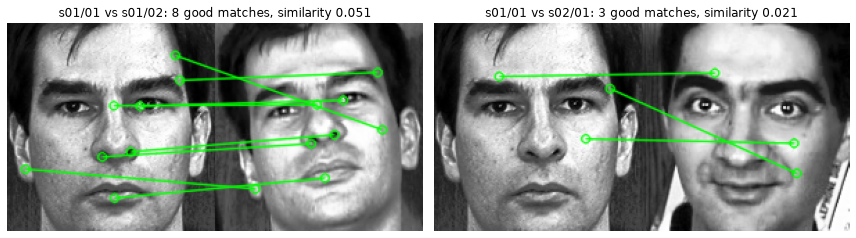

In [2]:
def show_matches(person1, index1, person2, index2, ax):
    f1, f2 = features[person1][index1], features[person2][index2]
    matches = good_matches(f1, f2)
    drawn = cv2.drawMatches(f1["face"], f1["keypoints"], f2["face"], f2["keypoints"], matches, None,
                            matchColor=(0, 255, 0), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    ax.imshow(drawn)
    ax.set_title(f"{person1}/{index1 + 1:02d} vs {person2}/{index2 + 1:02d}: "
                 f"{len(matches)} good matches, similarity {similarity(f1, f2):.3f}")
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show_matches("s01", 0, "s01", 1, axes[0])   # same person
show_matches("s01", 0, "s02", 0, axes[1])   # different people
plt.tight_layout()
plt.show()

## Part 2 — Choose the threshold on "calibration" people
For each person, photos 01–05 are the enrollment. Every other photo (06–15) of **every** person is used as a visitor.
- **Genuine attempt:** the visitor is the enrolled person.
- **Impostor attempt:** the visitor is someone else.

The people are split in half. The threshold is chosen on people s01–s25 only, so that it accepts at most **5% of impostors** (the false acceptance rate, FAR). The other 25 people are kept for an honest test in Part 3.

In [3]:
def attempt_scores(people):
    """Score every visitor photo against every enrolled person within the given group of people."""
    genuine, impostor = [], []
    for enrolled_person in people:
        enrolled = features[enrolled_person][:ENROLL_IMAGES]
        for visitor_person in people:
            for visitor in features[visitor_person][ENROLL_IMAGES:]:
                if visitor is None:
                    continue  # no face found: the system would ask the visitor to try again
                score = match_score(visitor, enrolled)
                (genuine if visitor_person == enrolled_person else impostor).append(score)
    return np.array(genuine), np.array(impostor)


calibration_people, test_people = PEOPLE[:len(PEOPLE) // 2], PEOPLE[len(PEOPLE) // 2:]
cal_genuine, cal_impostor = attempt_scores(calibration_people)

TARGET_FAR = 0.05
THRESHOLD = np.quantile(cal_impostor, 1 - TARGET_FAR)

print(f"Calibration people: {calibration_people[0]}-{calibration_people[-1]}")
print(f"Genuine attempts: {len(cal_genuine)}, impostor attempts: {len(cal_impostor)}")
print(f"Mean score - genuine: {cal_genuine.mean():.3f}, impostor: {cal_impostor.mean():.3f}")
print(f"Threshold for {TARGET_FAR:.0%} false acceptance: {THRESHOLD:.4f}")

Calibration people: s01-s25
Genuine attempts: 248, impostor attempts: 5952
Mean score - genuine: 0.096, impostor: 0.026
Threshold for 5% false acceptance: 0.0480


## Part 3 — Test on 25 people the threshold has never seen
Three numbers describe a verification system:
- **FAR (false acceptance rate):** the share of impostors let in. This is the security risk.
- **FRR (false rejection rate):** the share of genuine users turned away. This is the inconvenience.
- **ROC AUC:** the chance that a random genuine attempt scores higher than a random impostor attempt, at any threshold. 0.5 is guessing and 1.0 is perfect.

For comparison, the original method (comparing only keypoint *counts*) is scored on the same attempts.

Test people: s26-s50
Genuine attempts: 236, impostor attempts: 5664
ROC AUC: 0.932
At threshold 0.0480:  FAR = 6.8%   FRR = 17.8%
Original count-ratio method ROC AUC: 0.708


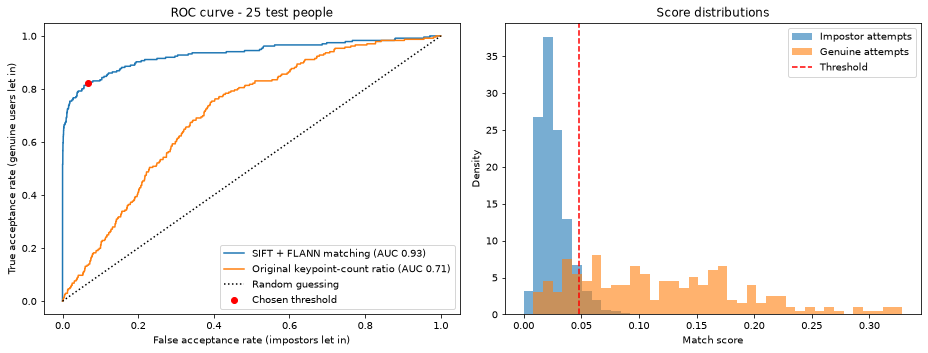

In [4]:
test_genuine, test_impostor = attempt_scores(test_people)

labels = np.r_[np.ones(len(test_genuine)), np.zeros(len(test_impostor))]
scores = np.r_[test_genuine, test_impostor]
auc = roc_auc_score(labels, scores)
far = (test_impostor >= THRESHOLD).mean()
frr = (test_genuine < THRESHOLD).mean()

print(f"Test people: {test_people[0]}-{test_people[-1]}")
print(f"Genuine attempts: {len(test_genuine)}, impostor attempts: {len(test_impostor)}")
print(f"ROC AUC: {auc:.3f}")
print(f"At threshold {THRESHOLD:.4f}:  FAR = {far:.1%}   FRR = {frr:.1%}")


# The original method, for comparison: ratio of keypoint COUNTS, (x/y + y/x) / 2, where 1.0 = identical counts
def count_ratio_score(visitor, enrolled_features):
    counts = [len(e["keypoints"]) for e in enrolled_features if e is not None and len(e["keypoints"])]
    c = len(visitor["keypoints"])
    return -np.mean([(c / e + e / c) / 2 for e in counts])  # negated so that higher = more similar


old_genuine, old_impostor = [], []
for enrolled_person in test_people:
    enrolled = features[enrolled_person][:ENROLL_IMAGES]
    for visitor_person in test_people:
        for visitor in features[visitor_person][ENROLL_IMAGES:]:
            if visitor is not None:
                (old_genuine if visitor_person == enrolled_person else old_impostor).append(
                    count_ratio_score(visitor, enrolled))
old_labels = np.r_[np.ones(len(old_genuine)), np.zeros(len(old_impostor))]
old_scores = np.r_[old_genuine, old_impostor]
print(f"Original count-ratio method ROC AUC: {roc_auc_score(old_labels, old_scores):.3f}")

# ROC curves and score distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fpr_new, tpr_new, _ = roc_curve(labels, scores)
fpr_old, tpr_old, _ = roc_curve(old_labels, old_scores)
axes[0].plot(fpr_new, tpr_new, label=f"SIFT + FLANN matching (AUC {auc:.2f})")
axes[0].plot(fpr_old, tpr_old, label=f"Original keypoint-count ratio (AUC {roc_auc_score(old_labels, old_scores):.2f})")
axes[0].plot([0, 1], [0, 1], "k:", label="Random guessing")
axes[0].scatter([far], [1 - frr], color="red", zorder=3, label="Chosen threshold")
axes[0].set_xlabel("False acceptance rate (impostors let in)")
axes[0].set_ylabel("True acceptance rate (genuine users let in)")
axes[0].set_title("ROC curve - 25 test people")
axes[0].legend()

bins = np.linspace(0, max(scores.max(), 0.3), 40)
axes[1].hist(test_impostor, bins=bins, alpha=0.6, density=True, label="Impostor attempts")
axes[1].hist(test_genuine, bins=bins, alpha=0.6, density=True, label="Genuine attempts")
axes[1].axvline(THRESHOLD, color="red", linestyle="--", label="Threshold")
axes[1].set_xlabel("Match score")
axes[1].set_ylabel("Density")
axes[1].set_title("Score distributions")
axes[1].legend()
plt.tight_layout()
plt.show()

## Part 4 — Access decision demo
Person **s26** (a test person) is enrolled with photos 01–05. Then all 10 of their other photos, plus 10 photos each of two other people, ask for access.

In [5]:
def request_access(enrolled_person, visitor):
    """Return True if the visitor's face matches the enrolled person strongly enough."""
    score = match_score(visitor, features[enrolled_person][:ENROLL_IMAGES])
    return score >= THRESHOLD, score


enrolled_person = "s26"
for visitor_person in ["s26", "s27", "s40"]:
    results = [request_access(enrolled_person, v) for v in features[visitor_person][ENROLL_IMAGES:] if v is not None]
    permitted = sum(ok for ok, _ in results)
    role = "genuine user" if visitor_person == enrolled_person else "impostor"
    print(f"{visitor_person} ({role}): {permitted}/{len(results)} photos permitted  "
          f"scores: {', '.join(f'{score:.3f}' for _, score in results)}")
print(f"Threshold: {THRESHOLD:.3f}")

s26 (genuine user): 7/8 photos permitted  scores: 0.211, 0.035, 0.177, 0.151, 0.126, 0.226, 0.097, 0.090
s27 (impostor): 0/8 photos permitted  scores: 0.019, 0.033, 0.019, 0.022, 0.026, 0.037, 0.023, 0.046
s40 (impostor): 0/10 photos permitted  scores: 0.027, 0.009, 0.027, 0.030, 0.019, 0.034, 0.016, 0.015, 0.023, 0.032
Threshold: 0.048


## Conclusions — approach 1
Matching SIFT descriptors (rather than counting keypoints) turns a weak system (AUC ≈ 0.7) into one that clearly separates genuine users from impostors. But at a 5% false acceptance rate, a noticeable share of genuine users are still rejected. Hand-crafted keypoints are sensitive to expression, lighting and head angle, which is exactly what this dataset varies. That isn't good enough for real access control, and it's why modern systems use learned face embeddings (approach 2).

## Approach 2 — deep face embeddings with dlib (`face_recognition`)
The pre-trained dlib ResNet model maps each face to a 128-dimensional embedding. A visitor is identified as the enrolled face with the smallest Euclidean distance, provided it's within the library's default tolerance of 0.6.

*Run on Google Colab, because dlib needs a C++ build toolchain on Windows. Code adapted from the DataFlair face-recognition tutorial (https://data-flair.training/blogs/python-face-recognition/).*

In [ ]:
# Colab only: install dependencies
!pip install face_recognition opencv-python

In [ ]:
import os

import cv2
import face_recognition as fr
import numpy as np

TRAIN_DIR = "./train/"          # one photo per known face, named e.g. Aidan01.jpg
TEST_IMAGE = "./test/test1.jpg"

known_names = []
known_name_encodings = []

for file_name in os.listdir(TRAIN_DIR):
    image_path = os.path.join(TRAIN_DIR, file_name)
    if not os.path.isfile(image_path):
        continue
    image = fr.load_image_file(image_path)             # loads as RGB
    encodings = fr.face_encodings(image)
    if not encodings:                                  # skip photos where no face is found
        print("No face found in", file_name)
        continue
    known_name_encodings.append(encodings[0])
    known_names.append(os.path.splitext(file_name)[0].capitalize())

print(known_names)

In [ ]:
# face_recognition expects RGB; OpenCV loads BGR, so convert before detecting and encoding
image_bgr = cv2.imread(TEST_IMAGE)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

face_locations = fr.face_locations(image_rgb)
face_encodings = fr.face_encodings(image_rgb, face_locations)

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
    face_distances = fr.face_distance(known_name_encodings, face_encoding)
    best_match = np.argmin(face_distances)
    # Accept the closest known face only if it is within the default tolerance (0.6)
    name = known_names[best_match] if face_distances[best_match] <= 0.6 else "Unknown"

    # Draw on the BGR image for OpenCV display
    cv2.rectangle(image_bgr, (left, top), (right, bottom), (0, 0, 255), 2)
    cv2.rectangle(image_bgr, (left, bottom - 15), (right, bottom), (0, 0, 255), cv2.FILLED)
    cv2.putText(image_bgr, name, (left + 6, bottom - 6), cv2.FONT_HERSHEY_DUPLEX, 1.0, (255, 255, 255), 1)

from google.colab.patches import cv2_imshow  # Colab replacement for cv2.imshow
cv2_imshow(image_bgr)
cv2.imwrite("./output.jpg", image_bgr)

### Results from the Colab run
Each test photo is labelled with the closest enrolled identity (names were assigned to the database's anonymous subject folders).

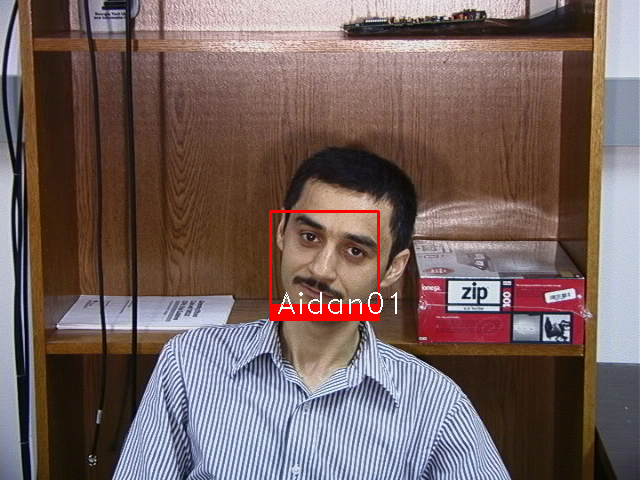

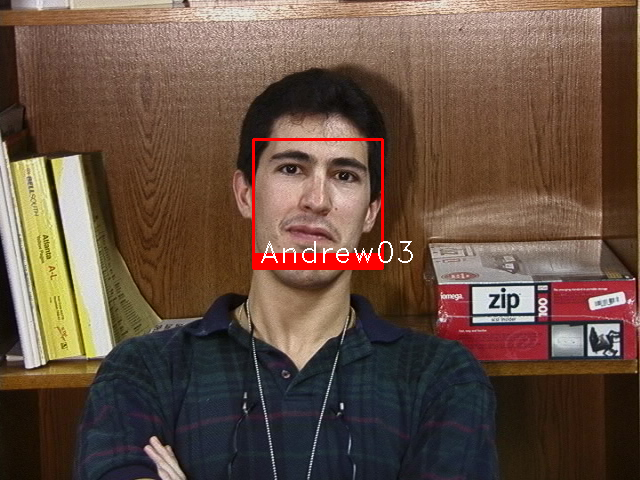

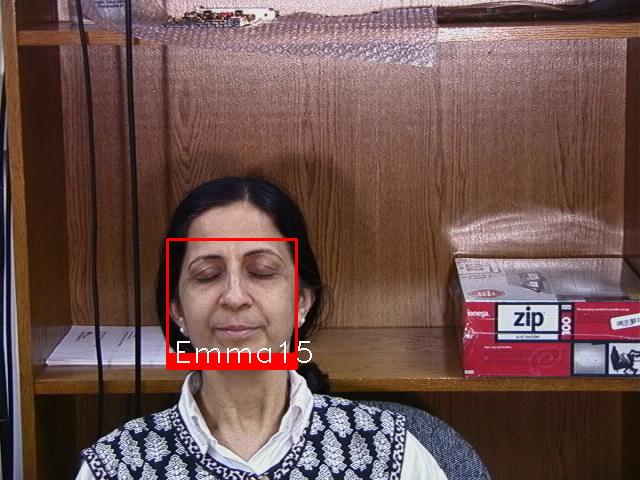

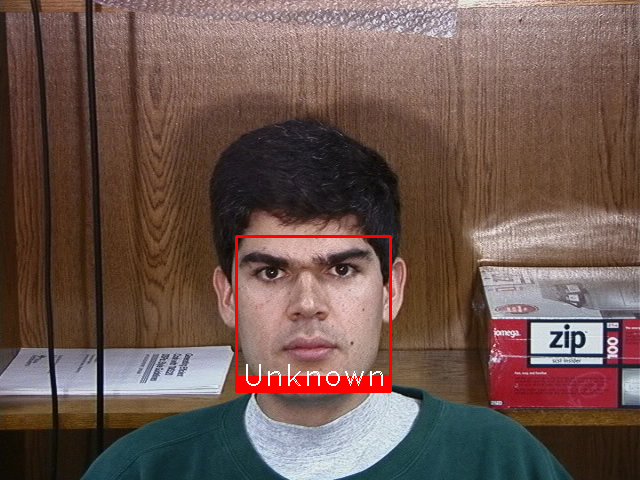

## Changes from the original submission
- **SIFT descriptors are now actually matched** (FLANN k-NN + Lowe's ratio test). The original compared keypoint *counts*, and the FLANN tutorial was cited but not used.
- **The decision rule was reversed.** The old score was lowest for similar counts, and a lower test score meant "permit". Now a higher match score means a stronger match.
- **Proper evaluation:** the threshold is chosen on 25 people and tested on 25 unseen people, with FAR, FRR, ROC AUC and a direct comparison with the original method. The original tested one impostor against one person.
- Faces are resized and histogram-equalized before feature extraction, only the largest detected face is used, and photos with no detected face are handled instead of causing a division by zero.
- dlib section: fixed the BGR/RGB mix-up, the incomplete `pip install`, and the crash when a training photo has no face. Matching now uses the distance tolerance directly.
- Removed absolute local paths and repeated code.